In [1]:
import sys
from pathlib import Path

# Adds 'dir1' (the parent directory) to Jupyter's path
sys.path.append(str(Path.cwd().parent))

import tps_pinn 


In [2]:
from scipy.stats import qmc
from scipy.io import loadmat
import numpy as np
import time
import matplotlib.pyplot as plt
import torch
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Por enunciado
# Puntos de colocación y de datos
N_PDE = 10000
N_BC = 1000
N_DATA = 10
# Pesos de ponderacion
LAMBDA_BC = 10
LAMBDA_PDE = 100
# Límites
X_LIM = (0, 1)
Y_LIM = (0, 1)
# Epocas de entrenamiento
EPOCHS = 50000


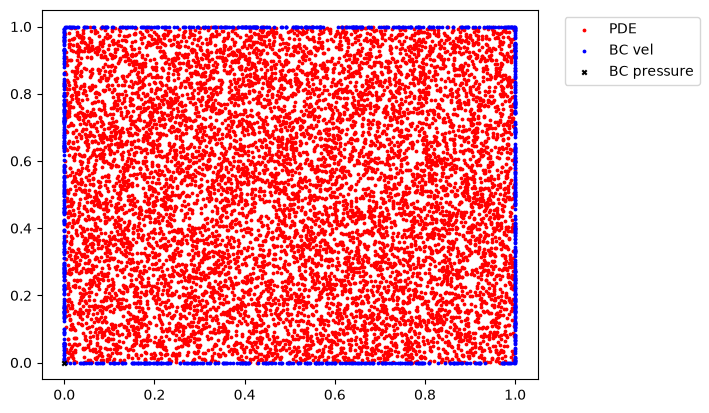

In [4]:
lhs = qmc.LatinHypercube(d=2)

X_pde = lhs.random(n=N_PDE)
X_pde = torch.tensor(X_pde)
X_bc_u, y_bc_u, X_bc_p, y_bc_p = tps_pinn.set_X_bc(N_BC)
tps_pinn.plot_points(X_pde, X_bc_u, X_bc_p)

In [5]:
# Importo data de ground truth
pressure_data = loadmat('../data/pressure.mat')
velocity_data = loadmat('../data/velocity.mat')
X_data_all = torch.tensor(np.hstack((pressure_data['x'].transpose(), pressure_data['y'].transpose())), dtype=torch.float32)
y_data_all = torch.tensor(np.hstack((pressure_data['p'].transpose(), velocity_data['u'].transpose(),velocity_data['v'].transpose())), dtype=torch.float32)


In [6]:
# Hiperparámetros
USE_DATA = False
HIDDEN_LAYERS = 3
HIDDEN_UNITS = 32
ACTIVATION = torch.nn.Tanh()

In [7]:
baseline_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'Re': 100,
    'device': device
}
tags = ['PDE', 'BC_VEL', 'BC_P']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]

baseline = tps_pinn.PINN(baseline_params).to(device)

In [8]:
start_time = time.perf_counter()
baseline, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt = tps_pinn.train_pinn(
    baseline,
    EPOCHS,
    dataset,
    device,
    USE_DATA,
    X_data_all, y_data_all,
    lambdas = {
        "pde": LAMBDA_PDE,
        "bc_u": LAMBDA_BC, 
        "bc_p": LAMBDA_BC, 
    }
)
baseline_time = time.perf_counter() - start_time
print(f"Tiempo de entrenamiento baseline: {baseline_time:.1f}s")

Comenzando entrenamiento del modelo...


/home/jiteich/repos/ceia/pinn_ceia/TPs/tps_pinn.py:112: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Epoch 0, PDE Loss: 6.608636, BC vel. Loss: 0.430096, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 10, PDE Loss: 6.481631, BC vel. Loss: 0.428616, BC pres. Loss: 0.000011, DATA Loss: N/A
Epoch 20, PDE Loss: 5.780531, BC vel. Loss: 0.414717, BC pres. Loss: 0.000183, DATA Loss: N/A
Epoch 30, PDE Loss: 5.078430, BC vel. Loss: 0.399164, BC pres. Loss: 0.000461, DATA Loss: N/A
Epoch 40, PDE Loss: 4.636928, BC vel. Loss: 0.388335, BC pres. Loss: 0.000638, DATA Loss: N/A
Epoch 50, PDE Loss: 4.287522, BC vel. Loss: 0.378615, BC pres. Loss: 0.000741, DATA Loss: N/A
Epoch 60, PDE Loss: 3.975584, BC vel. Loss: 0.368732, BC pres. Loss: 0.000762, DATA Loss: N/A
Epoch 70, PDE Loss: 3.676669, BC vel. Loss: 0.358422, BC pres. Loss: 0.000691, DATA Loss: N/A
Epoch 80, PDE Loss: 3.388743, BC vel. Loss: 0.348809, BC pres. Loss: 0.000539, DATA Loss: N/A
Epoch 90, PDE Loss: 3.126607, BC vel. Loss: 0.341160, BC pres. Loss: 0.000355, DATA Loss: N/A
Epoch 100, PDE Loss: 2.885286, BC vel. Loss: 0.335826, BC pre

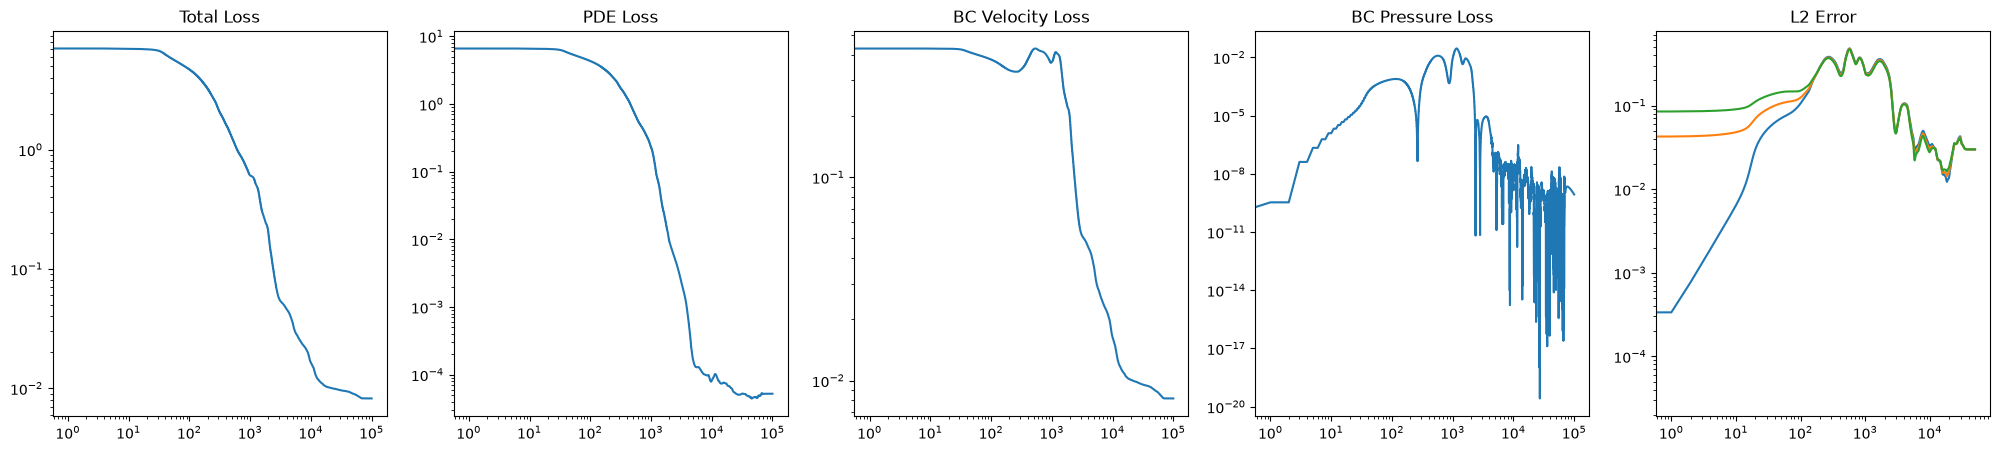

RAR-D (base) Error L-2 p: 0.0298
RAR-D (base) Error L-2 u: 0.0298
RAR-D (base) Error L-2 v: 0.0299


In [ ]:
if USE_DATA:
    loss_history = [pde + bc_vel + bc_p + data for pde, bc_vel, bc_p, data in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history)]
else:
    loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]

tps_pinn.plot_hist(loss_history, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, l2_error, use_data=USE_DATA, data_loss_history = data_loss_history)
print(f"LHS Error L-2 p: {l2_error[0][-1]:.4f}")
print(f"LHS Error L-2 u: {l2_error[1][-1]:.4f}")
print(f"LHS Error L-2 v: {l2_error[2][-1]:.4f}")